In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from jax import jit
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 10**-4.4904351e-05)  # constant metallicity (Z=0.02)
zmet = 1


ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

ssp_data.ssp_flux.shape

Z = 10**-4.4904351e-05
print(Z)

0.9998966092559682


Using combined (binwise + diffuse) dust attenuation.
Initializing Dust attenuation model...
Initializing DiffuseDust model...
Dust initialization complete.
Get spectrum with dust attenuation, without nebular contribution, and without dust emission.
dict_keys(['sfh_times', 'sfh', 'theta_init', 'alpha_idx', 'diffuse_dust_index_idx', 'diffuse_tau_kc_idx', 'sfh_idx', 'tau_pow_idx', 'zh_idx'])


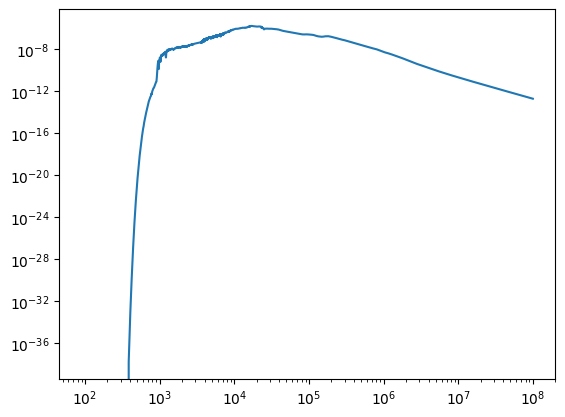

In [2]:
from sedpy_jax.observate import FilterSet as FSjax
from ceridwen.observation import Photometry

# example: one photometry observation using your FSjax filter set
fset = FSjax([
    'sdss_u0','sdss_g0','sdss_r0','sdss_i0','sdss_z0',
    'wise_w1','wise_w2',
    'jwst_f150w','jwst_f200w','jwst_f277w',
    'jwst_f356w','jwst_f444w'
])

phot_obs = Photometry(
    filters=[f.name for f in fset.filters],  # names
    flux=jnp.zeros(len(fset.filters)),       # dummy, not used in predict
    uncertainty=jnp.ones(len(fset.filters)), # dummy
    mask=jnp.ones(len(fset.filters), dtype=bool),
    name="phot_JADES"
)
# Make sure Photometry.set_filters uses FSjax internally:
phot_obs.filterset = fset

csp = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)

def run_spectrum(csp, theta):
    return csp.get_spectrum(theta)

# --- Compile the function, marking `csp` as static
run_spectrum_jit = jit(run_spectrum, static_argnums=0)


spec = run_spectrum_jit(csp, csp.theta_init)
plt.loglog(csp.wave, spec)


# Make the Forward Model class

In [3]:
import jax
import jax.numpy as jnp
from dataclasses import dataclass
from typing import Any, Tuple


In [ ]:
import jax
import jax.numpy as jnp


# ================================================================
# Stand-alone static function (this is what JAX wants)
# ================================================================
def run_spectrum(csp, theta):
    """
    csp : static object
    theta : JAX array (traced argument)
    """
    return csp.get_spectrum(theta)

def run_photometry(csp, phot, theta):
    """
    csp : static object
    phot : static object
    theta : JAX array (traced argument)
    """
    spec = csp.get_spectrum(theta)
    phot = phot.get_sed_maggies(csp.wave, spec)
    return phot


# ================================================================
# ForwardModel class
# ================================================================
class ForwardModel:
    """
    JAX-compatible forward model wrapper.
    Keeps CSP static, returns spectra via predict(theta).
    """

    def __init__(self, csp, observations):
        self.csp = csp
        self.observations = observations

        # Pre-jit the forward operation.
        # static_argnums=0 means the first argument (the CSP object) is static.
        self.run_spectrum_jit = jax.jit(run_spectrum, static_argnums=0)

    def _predict_spectrum(self, theta):
        """
        User-facing API: return spectrum at given theta.
        """
        return self.run_spectrum_jit(self.csp, theta)
    
    
    
    def _predict_phot(self, theta):
        """
        User-facing API: return photometry at given theta.
        """
        spec = self._predict_spectrum(theta)
        phot = self.observations.get_sed_maggies(self.csp.wave, spec)
        return phot

In [1]:
import jax
import jax.numpy as jnp


def run_spectrum(csp, theta):
    return csp.get_spectrum(theta)


class ForwardModel:
    def __init__(self, csp, observations):
        self.csp = csp
        self.observations = observations

        # jitted single-theta function (θ -> spectrum)
        self.run_spectrum_jit = jax.jit(run_spectrum, static_argnums=0)

        # vmapped version: takes a batch of θ and returns a batch of spectra
        # i.e. θ has shape (N, …)
        self.run_spectrum_vmap = jax.jit(
            jax.vmap(self.run_spectrum_jit, in_axes=(None, 0)),
            static_argnums=0
        )

    def predict(self, theta):
        return self.run_spectrum_jit(self.csp, theta)

    def predict_vmap(self, thetas):
        """
        thetas: array with shape (N, *theta_dim)
        """
        return self.run_spectrum_vmap(self.csp, thetas)
    

mod = ForwardModel(csp, phot_obs)

NameError: name 'csp' is not defined

In [6]:

def run_spectrum(csp, theta):
    return csp.get_spectrum(theta)

# --- Compile the function, marking `csp` as static
run_spectrum_jit = jax.jit(run_spectrum, static_argnums=0)

In [9]:
import time
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

# Benchmark sizes
Ns = [10, 100, 1000, 10_000, 100_000]

avg_times = []

theta0 = csp.theta_init
theta_dim = theta0.shape

# Largest batch size defines pool size
maxN = max(Ns)

key = jax.random.PRNGKey(0)
theta_pool = jax.random.normal(key, shape=(maxN,) + theta_dim)

# Warm-up: compile vmapped version
mod.predict_vmap(theta_pool[:10]).block_until_ready()

for N in Ns:
    batch = theta_pool[:N]

    start = time.perf_counter()
    out = mod.predict_vmap(batch).block_until_ready()
    end = time.perf_counter()

    avg = (end - start) / N
    avg_times.append(avg)

    print(f"N={N:>7d}   avg time per θ = {avg:.3e} s   "
          f"(total batch time = {(end - start):.3e} s)")

ValueError: Non-hashable static arguments are not supported. An error occurred while trying to hash an object of type <class 'jaxlib.xla_extension.ArrayImpl'>, [[ 1.6226422   2.0252647  -0.43359444 -0.07861735  0.1760909  -0.97208923
  -0.49529874  0.4943786   0.6643493  -0.9501635   2.1795304  -1.9551506
   0.35857072  0.15779513  1.2770847   1.5104648   0.970656    0.59960806
   0.0247007  -1.9164772  -1.8593491   1.728144    0.04719035  0.814128
   0.13132767  0.28284705  1.2435943   0.6902801  -0.80073744 -0.74099
  -1.5388287   0.30269185 -0.02071605  0.11328721 -0.2206547   0.07052256
   0.8532958  -0.8217738  -0.01461421 -0.15046217 -0.9001352  -0.7590727
   0.33309513  0.80924904  0.04269255 -0.57767123 -0.41439894 -1.9412533
   1.3161184   0.7542728   0.16170931 -0.03483307 -1.3306409   0.39362028
   0.48259583  0.80382955 -0.6337168   1.038756   -0.74159133 -0.4299588
  -0.22510043 -0.51966715 -1.6692165   0.67535436  0.22738722 -1.1800426
  -0.97673357  1.1969604  -0.8412756

In [ ]:
plt.figure(figsize=(7,5))
plt.loglog(Ns, avg_times, marker="o")
plt.xlabel("Batch size N")
plt.ylabel("Average time per θ [s]")
plt.title("Runtime scaling of vmapped predict_vmap")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

Array([0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.9856033e-13,
       1.9491430e-13, 1.9132608e-13], dtype=float32)

# Assembly

In [9]:
import jax
import jax.numpy as jnp


class ForwardModel:
    def __init__(self, csp, observation_list):
        """
        csp: your CSP model with JAX-compatible csp.get_spectrum(theta)
        observation_list: list of Observation objects
        """
        self.csp = csp
        self.observations = observation_list

        # capture wave ONCE as a Python object / static JAX array
        wave = jnp.asarray(csp.wave)

        # assemble blocks of the form f(spec) -> jnp.array
        blocks = []
        for obs in observation_list:
            blocks.append(
                lambda spec, _obs=obs, _wave=wave: _obs.predict_from_spec(spec, _wave)
            )

        self._blocks = tuple(blocks)

        # assemble the final forward model
        def predict(theta):
            spec = self.csp.get_spectrum(theta)
            outs = [block(spec) for block in self._blocks]
            return jnp.concatenate([jnp.ravel(out) for out in outs])

        self.predict = predict

    def jit_predict(self):
        return jax.jit(self.predict)

In [10]:
model = ForwardModel(csp=csp, observation_list=[phot_obs])

In [11]:
import jax

In [12]:

model = ForwardModel(csp=csp, observation_list=[phot_obs])

predict_jit = model.jit_predict()

theta = csp.theta_init  # or whatever shape your theta has

# first call → tracing + compilation
y1 = predict_jit(theta)

# second call → NO retracing
y2 = predict_jit(theta)

print("Result:", y1)
print("Difference:", jnp.max(jnp.abs(y1 - y2)))

Result: [5.5527821e+00 2.4801563e+01 7.3874199e+01 1.7625114e+02 4.2711279e+02
 8.5951973e+03 1.0439989e+04 2.6297339e+03 5.2162393e+03 6.2089219e+03
 9.2657949e+03 1.0312595e+04]
Difference: 0.0


In [13]:
phot_obs.get_sed_maggies(csp.wave, spec)

AttributeError: 'Photometry' object has no attribute 'get_sed_maggies'